<a href="https://colab.research.google.com/github/kilchinskiy/Hw.10.ipynb/blob/main/Hw_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Імпортуємо TensorFlow — основну бібліотеку для створення нейронних мереж
import tensorflow as tf

# Бібліотека з готовими датасетами (містить Fashion MNIST)
import tensorflow_datasets as tfds

# Бібліотека для побудови графіків
import matplotlib.pyplot as plt

# Бібліотека для роботи з масивами
import numpy as np

In [3]:
# Створюємо MLP модель
mlp_model = tf.keras.Sequential([

    # Вхідний шар
    tf.keras.Input(shape=(28,28,1)),

    # Перетворюємо 28x28 у вектор 784
    tf.keras.layers.Flatten(),

    # Повнозв'язний шар з 512 нейронами
    tf.keras.layers.Dense(512, activation='relu'),

    # Dropout для зменшення перенавчання
    tf.keras.layers.Dropout(0.4),

    # Другий повнозв'язний шар
    tf.keras.layers.Dense(256, activation='relu'),

    # Dropout
    tf.keras.layers.Dropout(0.3),

    # Вихідний шар (10 класів)
    tf.keras.layers.Dense(10, activation='softmax')
])

In [4]:
# Завантажуємо датасет Fashion MNIST з бібліотеки TensorFlow Datasets
# split=['train','test'] — розділяємо дані на тренувальну та тестову вибірку
# as_supervised=True — дані повертаються у форматі (зображення, мітка)
# with_info=True — додатково повертається інформація про датасет
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    "fashion_mnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.2H1MKK_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.2H1MKK_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [5]:
def normalize(image, label):                                 # Функція нормалізації зображень
    image = tf.cast(image, tf.float32) / 255.0                  # Перетворюємо тип даних зображення у float32
    return image, label

ds_train = ds_train.map(normalize).batch(128).prefetch(tf.data.AUTOTUNE)   # map(normalize) — застосовує функцію нормалізації до всіх зображень
ds_test = ds_test.map(normalize).batch(128).prefetch(tf.data.AUTOTUNE)     # Аналогічна підготовка для тестових даних

In [6]:
# Налаштовуємо параметри навчання MLP моделі
mlp_model.compile(
    # Adam — популярний оптимізатор для нейронних мереж
    # learning_rate — швидкість навчання моделі
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # sparse_categorical_crossentropy — функція втрат для багатокласової класифікації
    # використовується коли мітки представлені числами (0-9)
    loss='sparse_categorical_crossentropy',
    # accuracy — метрика оцінки точності класифікації
    metrics=['accuracy']
)

In [7]:
# Запускаємо навчання багатошарової мережі (MLP)
mlp_history = mlp_model.fit(
    ds_train,                 # Тренувальні дані
    epochs=30,                # Кількість проходів по всьому датасету
    validation_data=ds_test   # Тестові дані для перевірки якості моделі під час навчання
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7242 - loss: 0.7711 - val_accuracy: 0.8422 - val_loss: 0.4394
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8396 - loss: 0.4416 - val_accuracy: 0.8577 - val_loss: 0.4025
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8533 - loss: 0.3996 - val_accuracy: 0.8655 - val_loss: 0.3760
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8630 - loss: 0.3765 - val_accuracy: 0.8672 - val_loss: 0.3744
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8683 - loss: 0.3596 - val_accuracy: 0.8685 - val_loss: 0.3635
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8729 - loss: 0.3464 - val_accuracy: 0.8706 - val_loss: 0.3541
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8783 - loss: 0.3340 - val_accuracy: 0.8791 - val_loss: 0.3406
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8801 - loss: 0.3269 - val_accuracy:

In [8]:
# Створюємо згорткову нейронну мережу (CNN)
cnn_model = tf.keras.Sequential([
    # Вхідний шар — визначає розмір вхідного зображення
    # 28x28 пікселів та 1 канал (чорно-біле зображення)
    tf.keras.Input(shape=(28,28,1)),
    # Перший згортковий шар
    # 64 фільтри розміром 3x3
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    # BatchNormalization — нормалізує значення активацій
    tf.keras.layers.BatchNormalization(),
    # MaxPooling — зменшує розмір карти ознак
    tf.keras.layers.MaxPooling2D(2,2),
    # Другий згортковий шар
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    # Нормалізація
    tf.keras.layers.BatchNormalization(),
    # Зменшення розмірності
    tf.keras.layers.MaxPooling2D(2,2),
    # Третій згортковий шар
    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    # Нормалізація
    tf.keras.layers.BatchNormalization(),
    # Flatten — перетворює 2D карту ознак у 1D вектор
    tf.keras.layers.Flatten(),
    # Повнозв'язний шар з 256 нейронами
    tf.keras.layers.Dense(256, activation='relu'),
    # Dropout — вимикає 40% нейронів під час навчання
    # допомагає боротися з перенавчанням
    tf.keras.layers.Dropout(0.4),
    # Вихідний шар
    # 10 нейронів — по одному для кожного класу
    tf.keras.layers.Dense(10, activation='softmax')
])

In [9]:
# EarlyStopping — зупиняє навчання,
# якщо validation accuracy не покращується
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',      # слідкуємо за валідаційною помилкою
    patience=5,              # чекаємо 5 епох без покращення
    restore_best_weights=True
)

# ReduceLROnPlateau — зменшує learning rate,
# якщо модель перестає покращуватись
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',      # слідкуємо за val_loss
    factor=0.5,              # зменшуємо LR в 2 рази
    patience=3,              # якщо 3 епохи без покращення
    verbose=1
)

In [10]:
# Налаштовуємо процес навчання CNN моделі
cnn_model.compile(
    # Оптимізатор Adam з меншою швидкістю навчання
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    # Функція втрат
    loss='sparse_categorical_crossentropy',
    # Метрика оцінки
    metrics=['accuracy']
)

In [11]:
# Запускаємо навчання згорткової нейронної мережі
cnn_history = cnn_model.fit(
    ds_train,                         # Тренувальні дані
    epochs=35,                       # Максимальна кількість епох
    validation_data=ds_test,           # Дані для валідації
    # callbacks:
    # early_stop — зупиняє навчання якщо модель перестала покращуватись
    # reduce_lr — зменшує learning rate якщо прогрес зупинився
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8071 - loss: 0.6157 - val_accuracy: 0.6796 - val_loss: 2.6243 - learning_rate: 5.0000e-04
Epoch 2/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8934 - loss: 0.2953 - val_accuracy: 0.9065 - val_loss: 0.2787 - learning_rate: 5.0000e-04
Epoch 3/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9142 - loss: 0.2383 - val_accuracy: 0.9105 - val_loss: 0.2798 - learning_rate: 5.0000e-04
Epoch 4/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9284 - loss: 0.1942 - val_accuracy: 0.9113 - val_loss: 0.2716 - learning_rate: 5.0000e-04
Epoch 5/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9387 - loss: 0.1644 - val_accuracy: 0.9070 - val_loss: 0.2874 - learning_rate: 5.0000e-04
Epoch 6/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9464 - loss: 0.1448 - val_accuracy: 0.9115 - val_loss: 0.3000 - learning_rate: 5.0000e-04
Epoch 7/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - ac

In [12]:
mlp_loss, mlp_acc = mlp_model.evaluate(ds_test)     # Оцінюємо точність MLP моделі на тестових даних
cnn_loss, cnn_acc = cnn_model.evaluate(ds_test)     # Оцінюємо точність CNN моделі

print("MLP accuracy:", mlp_acc)      # Виводимо точність багатошарової мережі
print("CNN accuracy:", cnn_acc)      # Виводимо точність згорткової мережі

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.3048
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9120 - loss: 0.2757
MLP accuracy: 0.8917999863624573
CNN accuracy: 0.911300003528595


In [13]:
# Імпортуємо TensorFlow
import tensorflow as tf

# Бібліотека з готовими датасетами
import tensorflow_datasets as tfds

# Бібліотека для роботи з масивами
import numpy as np

In [14]:
# Завантажуємо Fashion MNIST
# train – 60000 зображень
# test – 10000 зображень
(ds_train, ds_test), ds_info = tfds.load(
    "fashion_mnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

In [15]:
# Функція попередньої обробки зображень
def preprocess(image, label):

    # Нормалізуємо значення пікселів (0-255 → 0-1)
    image = tf.cast(image, tf.float32) / 255.0

    # Змінюємо розмір зображення
    # VGG16 потребує більші зображення
    image = tf.image.resize(image, (96,96))

    # Робимо 3 канали (RGB), бо VGG16 очікує 3 канали
    image = tf.image.grayscale_to_rgb(image)

    return image, label

In [16]:
# Застосовуємо preprocessing
# cache() прискорює роботу
# batch – кількість зображень у пакеті
# prefetch – оптимізація завантаження

ds_train = ds_train.map(preprocess).cache().batch(128).prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.map(preprocess).cache().batch(128).prefetch(tf.data.AUTOTUNE)

In [17]:
# Завантажуємо попередньо навчену модель VGG16
# include_top=False – прибираємо верхні класифікаційні шари
# weights="imagenet" – використовуємо ваги з ImageNet

base_model = tf.keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96,96,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [18]:
# Заморожуємо згорткову частину
# ваги VGG16 не змінюються
base_model.trainable = False

In [19]:
# Створюємо нову модель на основі VGG16
model = tf.keras.Sequential([

    # Згорткова основа
    base_model,

    # Перетворюємо карту ознак у вектор
    tf.keras.layers.Flatten(),

    # Повнозв'язний шар
    tf.keras.layers.Dense(256, activation="relu"),

    # Dropout для боротьби з перенавчанням
    tf.keras.layers.Dropout(0.5),

    # Вихідний шар (10 класів)
    tf.keras.layers.Dense(10, activation="softmax")

])

In [20]:
# Налаштовуємо процес навчання
model.compile(

    # Оптимізатор Adam
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    # Функція втрат
    loss="sparse_categorical_crossentropy",

    # Метрика точності
    metrics=["accuracy"]

)

In [21]:
# Навчання моделі
history = model.fit(

    # тренувальні дані
    ds_train,

    # кількість епох
    epochs=5,

    # тестові дані
    validation_data=ds_test

)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 201ms/step - accuracy: 0.6730 - loss: 0.9814 - val_accuracy: 0.8598 - val_loss: 0.3913
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.8586 - loss: 0.4081 - val_accuracy: 0.8784 - val_loss: 0.3400
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.8792 - loss: 0.3506 - val_accuracy: 0.8868 - val_loss: 0.3139
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.8876 - loss: 0.3194 - val_accuracy: 0.8920 - val_loss: 0.2999
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.8953 - loss: 0.2974 - val_accuracy: 0.8968 - val_loss: 0.2862


In [22]:
# Розморожуємо верхні шари VGG16
base_model.trainable = True

# Заморожуємо всі шари крім останніх
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [23]:
# Налаштовуємо параметри навчання моделі
model.compile(

    # Оптимізатор Adam з дуже маленькою швидкістю навчання
    # Це потрібно для донавчання (fine-tuning), щоб не зіпсувати
    # вже навчені ваги моделі VGG16
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    # Функція втрат для задачі багатокласової класифікації
    # Використовується коли мітки представлені числами (0-9)
    loss="sparse_categorical_crossentropy",
    # Метрика оцінки якості моделі — точність класифікації
    metrics=["accuracy"]

)

In [24]:
# Запускаємо донавчання моделі
history_fine = model.fit(
     # Тренувальні дані
    ds_train,
    # Кількість епох навчання
    # Тут використовуємо невелику кількість, щоб не перенавчити модель
    epochs=3,
     # Тестові дані для перевірки якості моделі під час навчання
    validation_data=ds_test

)

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 210ms/step - accuracy: 0.9057 - loss: 0.2652 - val_accuracy: 0.9088 - val_loss: 0.2535
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - accuracy: 0.9218 - loss: 0.2196 - val_accuracy: 0.9128 - val_loss: 0.2408
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 197ms/step - accuracy: 0.9324 - loss: 0.1924 - val_accuracy: 0.9162 - val_loss: 0.2313


In [25]:
# Оцінюємо модель на тестовій вибірці
# evaluate повертає значення функції втрат (loss) і точність (accuracy)
loss, acc = model.evaluate(ds_test)
# Виводимо точність моделі VGG16
print("VGG16 accuracy:", acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.9195 - loss: 0.2261
VGG16 accuracy: 0.9161999821662903


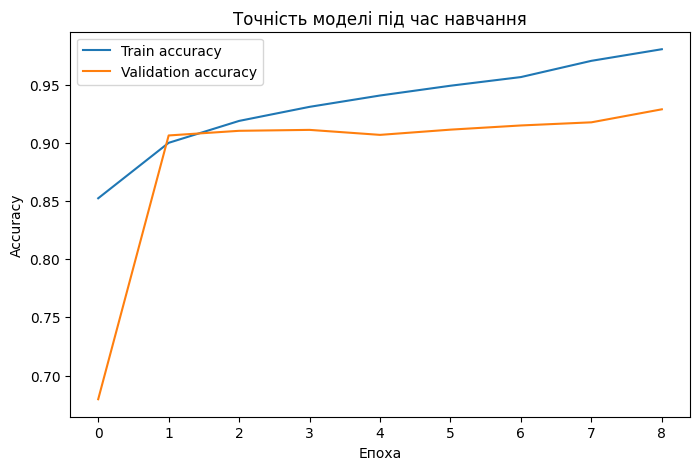

In [29]:
# Створюємо нову фігуру для побудови графіка
# figsize задає розмір графіка
plt.figure(figsize=(8,5))

# Будуємо графік точності на тренувальних даних
# cnn_history.history['accuracy'] містить значення точності після кожної епохи навчання
plt.plot(cnn_history.history['accuracy'], label='Train accuracy')

# Будуємо графік точності на валідаційних (тестових) даних
# val_accuracy показує, як модель працює на даних, які не використовувалися для навчання
plt.plot(cnn_history.history['val_accuracy'], label='Validation accuracy')

# Додаємо заголовок графіка
plt.title('Точність моделі під час навчання')

# Підпис осі X (номер епохи)
plt.xlabel('Епоха')

# Підпис осі Y (значення точності)
plt.ylabel('Accuracy')

# Додаємо легенду для пояснення ліній графіка
plt.legend()

# Відображаємо графік
plt.show()

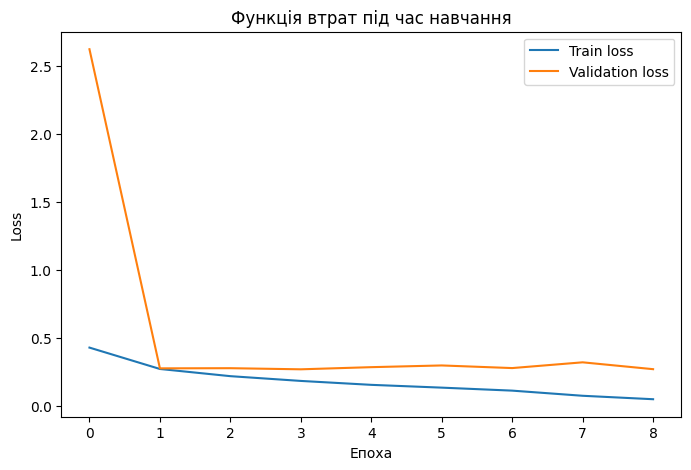

In [30]:
# Графік функції втрат (Loss)

# Створюємо нову фігуру для графіка
plt.figure(figsize=(8,5))

# Будуємо графік функції втрат для тренувальних даних
# loss показує величину помилки моделі
plt.plot(cnn_history.history['loss'], label='Train loss')

# Будуємо графік функції втрат для валідаційних даних
plt.plot(cnn_history.history['val_loss'], label='Validation loss')

# Додаємо заголовок графіка
plt.title('Функція втрат під час навчання')

# Підпис осі X
plt.xlabel('Епоха')

# Підпис осі Y
plt.ylabel('Loss')

# Додаємо легенду
plt.legend()

# Відображаємо графік
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


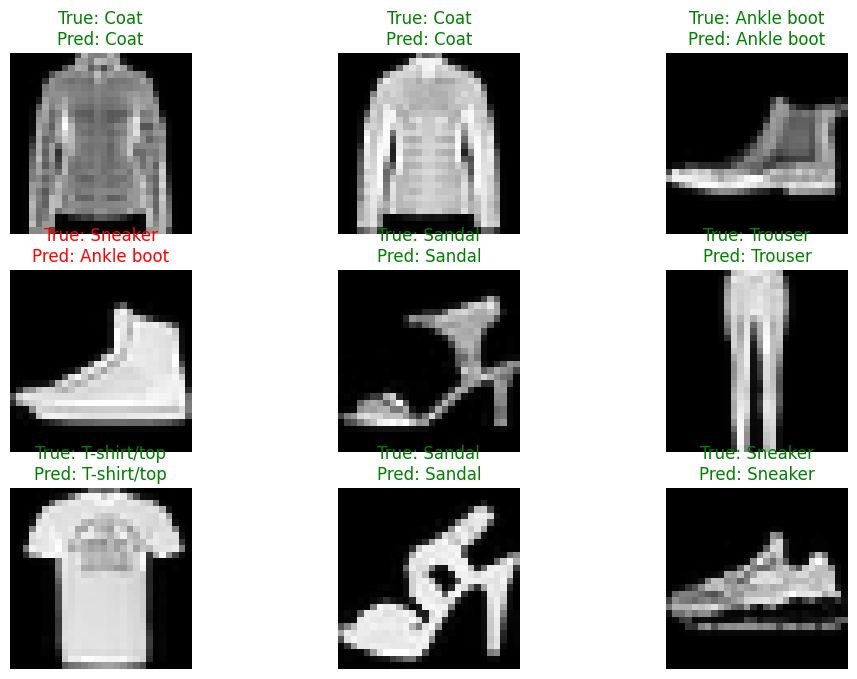

In [35]:
# Візуалізація класифікації зображень

# список класів Fashion-MNIST
class_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

# беремо 9 зображень
for images, labels in ds_test.unbatch().batch(9).take(1):

    # перетворюємо дані до формату CNN
    images_cnn = tf.image.resize(images, (28,28))
    images_cnn = tf.image.rgb_to_grayscale(images_cnn)

    # отримуємо прогноз моделі
    predictions = cnn_model.predict(images_cnn)

    plt.figure(figsize=(12,8))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images_cnn[i].numpy().squeeze(), cmap='gray')

        true_label = class_names[labels[i]]
        predicted_label = class_names[np.argmax(predictions[i])]

        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)

        plt.axis('off')

    plt.show()